# Feature Importance and Model Interpretability

In this notebook we analyze feature importance in regression models.

We demonstrate:

- Lasso-based feature importance
- Permutation importance
- Understanding feature impact on predictions

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso

from sklearn.inspection import permutation_importance

In [2]:
# Load Dataset#
df = pd.read_csv("../data/house_prices.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Feature Selection

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd"
]

X = df[features]
y = df["SalePrice"]

In [4]:
# Handle Missing Values
X = X.fillna(X.mean())

In [5]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Train Lasso Model
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [7]:
# Lasso Feature Importance
coefficients = pd.Series(
    lasso.coef_,
    index=X.columns
)

coefficients.sort_values()

FullBath        -5755.175392
1stFlrSF           14.497067
TotalBsmtSF        14.905811
GrLivArea          49.062208
TotRmsAbvGrd      183.424220
YearBuilt         363.023523
GarageCars      14762.518551
OverallQual     20903.386136
dtype: float64

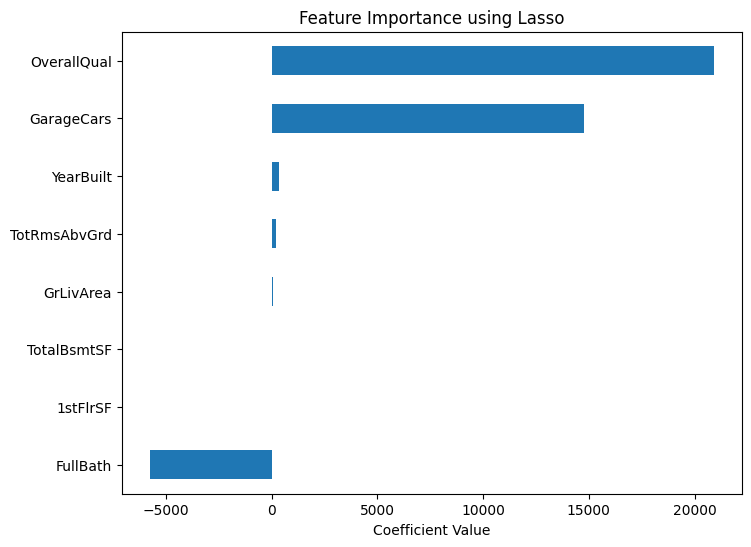

In [8]:
# Visualization (Lasso Importance)
coefficients.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance using Lasso")
plt.xlabel("Coefficient Value")

plt.show()

In [9]:
# Permutation Importance
results = permutation_importance(
    lasso,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

In [10]:
# Convert to DataFrame
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": results.importances_mean
})

importance_df = importance_df.sort_values(by="importance")

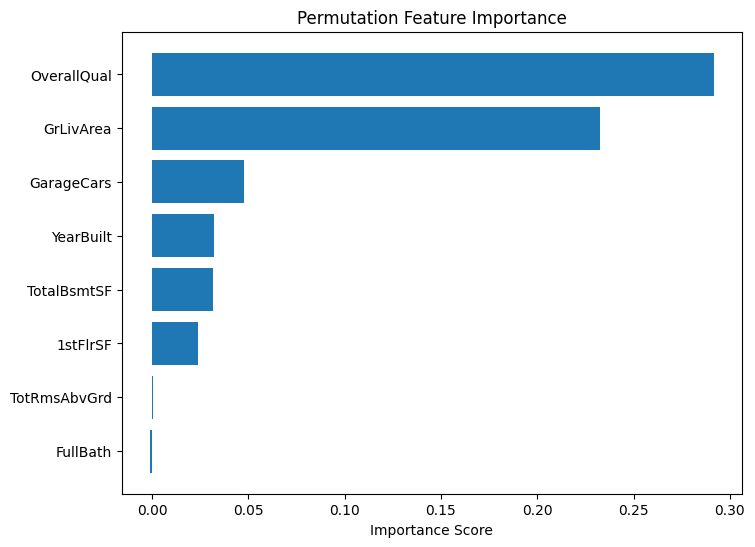

In [11]:
# Visualization (Permutation Importance)
plt.figure(figsize=(8,6))

plt.barh(importance_df["feature"], importance_df["importance"])

plt.title("Permutation Feature Importance")
plt.xlabel("Importance Score")

plt.show()

## Key Insights

- Lasso regression assigns higher weights to important features.
- Some features may have near-zero coefficients, indicating low importance.
- Permutation importance measures how model performance changes when a feature is shuffled.
- Features like OverallQual and GrLivArea typically have high importance in predicting house prices.